In [ ]:
import pandas as pd
import os
import json
import sys
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option('display.max_columns', None)


In [4]:
from pathlib import Path
import sys

# Robustly locate repo root (works no matter your notebook CWD)
cwd = Path.cwd().resolve()
repo_root = None
for p in [cwd, *cwd.parents]:
    if (p / "qmsum_to_pandas.py").exists():
        repo_root = p
        break
if repo_root is None:
    raise FileNotFoundError("Could not locate repo root containing data/src/qmsum_to_pandas.py")

sys.path.insert(0, str((repo_root / "data" ).resolve()))

from qmsum_to_pandas import load_qmsum_split_as_dfs
from qmsum_to_pandas import score_meetings_for_conflict_resolution
from communication_effectiveness import score_qmsum_meeting_communication

# Load one dataset split into 4 tidy tables
# Options: dataset in {"Product","Academic","Committee","ALL"}; split in {"train","val","test","all"}

types = ["Academic", "Product", "Committee"]
meetings_list, transcripts_list, topics_list, queries_list = [], [], [], []

for type in types:
    df = load_qmsum_split_as_dfs(dataset=type, split="all", prefer_jsonl=True)

    meetings_list.append(df.meetings)
    transcripts_list.append(df.transcripts)
    topics_list.append(df.topics)
    queries_list.append(df.queries)

meetings_df    = pd.concat(meetings_list, ignore_index=True)
transcripts_df = pd.concat(transcripts_list, ignore_index=True)
topics_df      = pd.concat(topics_list, ignore_index=True)
queries_df     = pd.concat(queries_list, ignore_index=True)

In [5]:
queries_df.head()

,dataset,split,meeting_id,query_type,query_idx,query,answer,span_idx,span_start_turn,span_end_turn
0,Academic,all,Bdb001,general,0,Summarize the whole meeting,Meeting participants wanted to agree upon a st...,NaN,NaN,NaN
1,Academic,all,Bdb001,specific,0,Summarize the discussion about the current XML...,C developed an XML format that links together ...,0.0,19.0,89.0
2,Academic,all,Bdb001,specific,1,What did F think about the current XML format ...,F was concerned about how the time labels woul...,0.0,51.0,87.0
3,Academic,all,Bdb001,specific,2,What did A think about the current XML format ...,A had seen an example of this kind of XML form...,0.0,56.0,77.0
4,Academic,all,Bdb001,specific,3,Summarize the discussion about the disadvantag...,Since the team is familiar with Perl and a fla...,0.0,463.0,594.0


In [6]:
meetings_df.head()

,dataset,split,meeting_id,n_turns,n_topics,n_general_queries,n_specific_queries,meeting_text,meeting_text_chars,meeting_text_words
0,Academic,all,Bdb001,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505
1,Academic,all,Bed002,533,5,1,6,"Grad E: I guess .\nGrad A: OK , we 're on . So...",64174,14927
2,Academic,all,Bed003,1029,3,1,6,Grad C: Nice .\nGrad D: OK .\nGrad A: to to ha...,65809,15318
3,Academic,all,Bed004,374,4,1,6,"Grad A: Hey , you 're not supposed to be drink...",43849,9954
4,Academic,all,Bed005,709,4,1,4,"Grad A: Yeah , I think I got my mike on . OK ....",63869,15079


In [7]:
topics_df.head()

,dataset,split,meeting_id,topic_idx,topic,span_idx,span_start_turn,span_end_turn
0,Academic,all,Bdb001,0,Current XML format to link up different compon...,0,19,89
1,Academic,all,Bdb001,1,Best way to store features,0,90,197
2,Academic,all,Bdb001,2,Exploring NIST's ATLAS as a potential storage ...,0,198,460
3,Academic,all,Bdb001,3,Disadvantages of ATLAS and other options,0,463,594
4,Academic,all,Bdb001,4,Handling annotations,0,595,760


In [ ]:
transcripts_df.head()

,dataset,split,meeting_id,turn_idx,speaker,content,content_clean,n_chars,n_words
0,Academic,all,Bdb001,0,Grad C,"Yeah , we had a long discussion about how much...","Yeah , we had a long discussion about how much...",143,33
1,Academic,all,Bdb001,1,PhD D,It {disfmarker} it doesn't {disfmarker},It it doesn't,13,3
2,Academic,all,Bdb001,2,Grad C,Did {disfmarker} did {disfmarker} did it {disf...,Did did did it ? I didn't even check yesterday...,70,15
3,Academic,all,Bdb001,3,PhD D,It didn't move yesterday either when I started...,It didn't move yesterday either when I started...,51,10
4,Academic,all,Bdb001,4,Grad C,So .,So .,4,2


### Meetings EDA

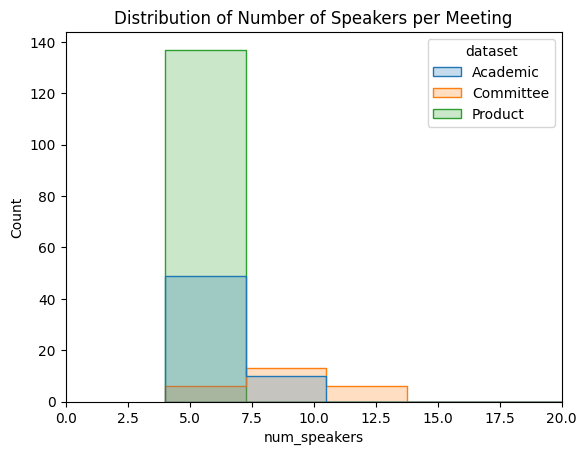

In [9]:
# How many speakers in each meeting?
num_speaker_df = transcripts_df.groupby(["dataset", "meeting_id"])["speaker"].nunique().reset_index(name="num_speakers")
sns.histplot(
    data=num_speaker_df,
    x="num_speakers",
    hue="dataset",
    element="step",
    common_norm=False,
    )
plt.title("Distribution of Number of Speakers per Meeting")
plt.xlim(0, 20)
plt.show()


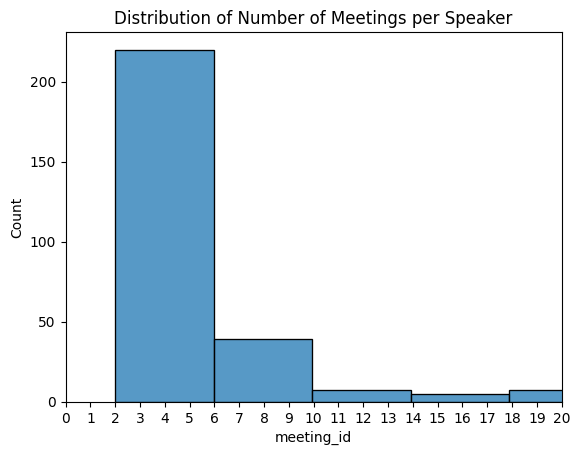

In [10]:
# Do we see the same speaker in different meetings?
speaker_meeting_counts = (
    transcripts_df.groupby("speaker")["meeting_id"]
    .nunique()
    .sort_values(ascending=False)
)

speakers_in_multiple_meetings = speaker_meeting_counts[speaker_meeting_counts > 1]
sns.histplot(speakers_in_multiple_meetings)
plt.title("Distribution of Number of Meetings per Speaker")
plt.xlim(0, 20)
plt.xticks(range(0, 21, 1))
plt.show()


In [11]:
# List of meetings each speaker has participated in
speaker_to_meetings = (
    transcripts_df.groupby(["dataset", "speaker"])["meeting_id"]
    .apply(lambda s: sorted(set(s)))
    .reset_index(name="meeting_ids")
)

speaker_to_meetings[speaker_to_meetings["meeting_ids"].str.len() > 1]

,dataset,speaker,meeting_ids
0,Academic,Grad A,"[Bed002, Bed003, Bed004, Bed005, Bed008, Bed01..."
1,Academic,Grad B,"[Bdb001, Bed002, Bed003, Bed006, Bed009, Bed01..."
2,Academic,Grad C,"[Bdb001, Bed003, Bed004, Bed005, Bed006, Bed00..."
3,Academic,Grad D,"[Bed002, Bed003, Bed004, Bed005, Bed008, Bed00..."
4,Academic,Grad E,"[Bed002, Bed005, Bed006, Bed008, Bed009, Bed01..."
...,...,...,...
518,Committee,Vikki Howells AM,"[education_12, education_13]"
519,Product,Industrial Designer,"[ES2002a, ES2002b, ES2002c, ES2002d, ES2003a, ..."
520,Product,Marketing,"[ES2002a, ES2002b, ES2002c, ES2002d, ES2003a, ..."
521,Product,Project Manager,"[ES2002a, ES2002b, ES2002c, ES2002d, ES2003a, ..."


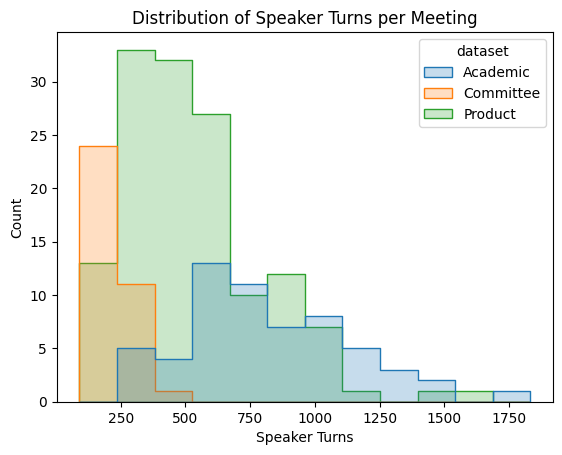

In [12]:
# How many times people spoke in each meeting? This is a signal of flow and engagement, but likely depends on topic and type of meeting.
per_meeting = (
    transcripts_df.groupby(["dataset", "meeting_id"], dropna=False)
    .size()
    .reset_index(name="Speaker Turns")
)

sns.histplot(
    data=per_meeting,
    x="Speaker Turns",
    hue="dataset",
    element="step",
    common_norm=False,
    )

plt.title("Distribution of Speaker Turns per Meeting")
plt.show()

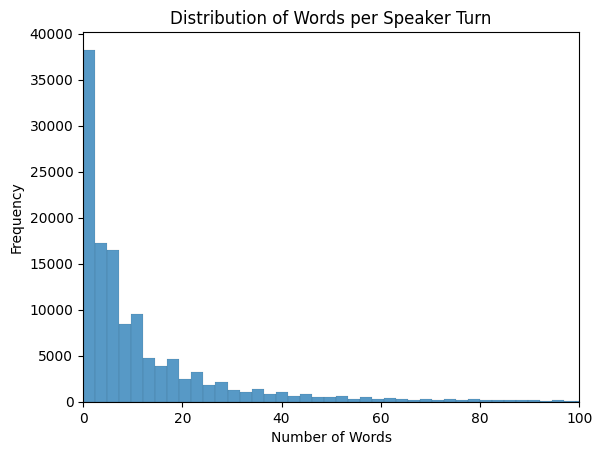

In [13]:
# Distribution of words for each time someone spoke.
sns.histplot(transcripts_df["n_words"])
plt.xlabel("Number of Words")
plt.xlim(0, 100)
plt.ylabel("Frequency")
plt.title("Distribution of Words per Speaker Turn")
plt.show()

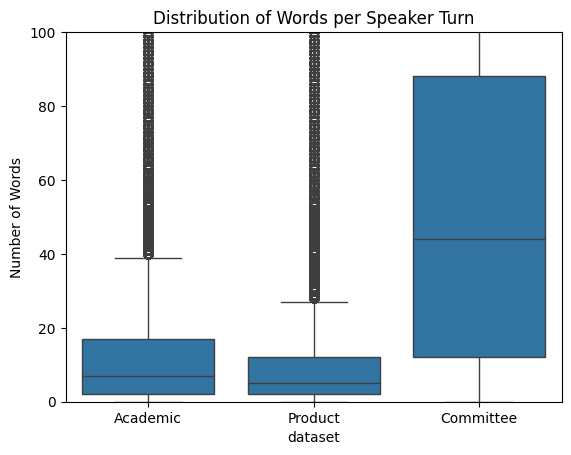

In [14]:
# How many words were said each time someone spoke?
sns.boxplot(
    y="n_words",
    x="dataset",
    data=transcripts_df,
    )
plt.ylabel("Number of Words")
plt.title("Distribution of Words per Speaker Turn")
plt.ylim(0, 100)
plt.show()


In [15]:
counts = (
    transcripts_df.groupby(["dataset", "meeting_id", "speaker"], dropna=False)
    .size()
    .reset_index(name="n_turns")
    .sort_values(["meeting_id", "n_turns"], ascending=[True, False])
)

speaker_spread_df = counts.groupby(["dataset", "meeting_id"]).agg(
    n_speakers=("speaker", "nunique"),
    n_turns=("n_turns", "sum"),
    mean_turns_per_speaker=("n_turns", "mean"),
    median_turns_per_speaker=("n_turns", "median"),
    var_turns_per_speaker=("n_turns", "var"),
    std_turns_per_speaker=("n_turns", "std"),
    ).reset_index()
    
speaker_spread_df

,dataset,meeting_id,n_speakers,n_turns,mean_turns_per_speaker,median_turns_per_speaker,var_turns_per_speaker,std_turns_per_speaker
0,Academic,Bdb001,6,766,127.666667,106.5,12662.666667,112.528515
1,Academic,Bed002,6,533,88.833333,76.0,3765.366667,61.362584
2,Academic,Bed003,4,1029,257.250000,253.0,463.583333,21.530985
3,Academic,Bed004,4,374,93.500000,103.0,2533.666667,50.335541
4,Academic,Bed005,6,709,118.166667,89.0,7089.766667,84.200752
...,...,...,...,...,...,...,...,...
227,Product,TS3011c,4,622,155.500000,168.0,4723.000000,68.724086
228,Product,TS3011d,4,668,167.000000,172.5,3895.333333,62.412606
229,Product,TS3012a,4,203,50.750000,48.0,330.250000,18.172782
230,Product,TS3012b,4,958,239.500000,213.0,8761.666667,93.603775


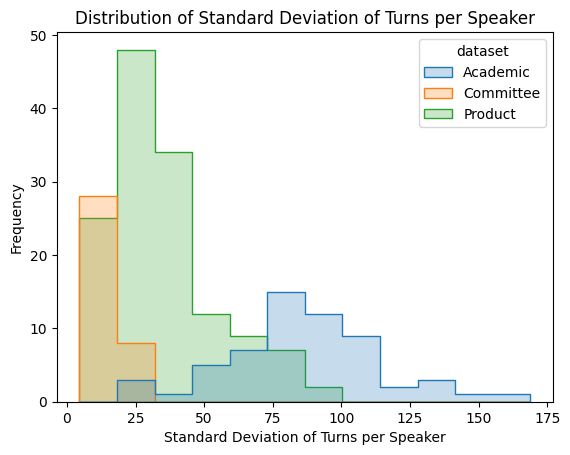

In [16]:
# Were the meetings balanced in terms of how often a speaker spoke? I investigate spread to see how often speaker imbalances occurred.
df = speaker_spread_df[["dataset", "std_turns_per_speaker"]]

sns.histplot(
    df,
    x="std_turns_per_speaker",
    hue="dataset",
    element="step",
    common_norm=False,
    )
plt.xlabel("Standard Deviation of Turns per Speaker")
plt.ylabel("Frequency")
plt.title("Distribution of Standard Deviation of Turns per Speaker")
plt.show()

This probably needs to be taken into consideration along with the meeting topic.

### Topics EDA

In [17]:
topics_df["topic_duration"] = topics_df["span_end_turn"] - topics_df["span_start_turn"]
topics_df

,dataset,split,meeting_id,topic_idx,topic,span_idx,span_start_turn,span_end_turn,topic_duration
0,Academic,all,Bdb001,0,Current XML format to link up different compon...,0,19,89,70
1,Academic,all,Bdb001,1,Best way to store features,0,90,197,107
2,Academic,all,Bdb001,2,Exploring NIST's ATLAS as a potential storage ...,0,198,460,262
3,Academic,all,Bdb001,3,Disadvantages of ATLAS and other options,0,463,594,131
4,Academic,all,Bdb001,4,Handling annotations,0,595,760,165
...,...,...,...,...,...,...,...,...,...
1109,Committee,all,education_9,2,Potential unintended consequences of connectio...,0,45,87,42
1110,Committee,all,education_9,3,Concerns of the preparations for the implement...,0,90,111,21
1111,Committee,all,education_9,4,"Government's assessment, progression and accou...",0,113,149,36
1112,Committee,all,education_9,5,Human rights and resources embedded in the new...,0,151,180,29


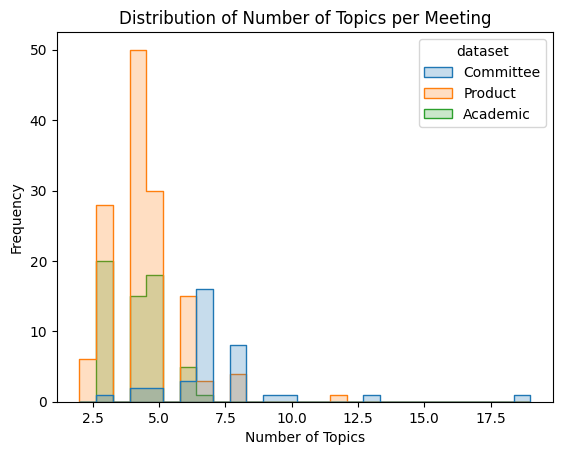

In [18]:
# How many topics per meeting? Typically meetings should have a few topics, and I wonder if more topics means less effective meetings.
num_topics_df = topics_df[["dataset", "meeting_id"]].value_counts().reset_index(name="count")

sns.histplot(
    data=num_topics_df,
    x="count",
    hue="dataset",
    element="step",
    common_norm=False,
    )
plt.xlabel("Number of Topics")
plt.ylabel("Frequency")
plt.title("Distribution of Number of Topics per Meeting")
plt.show()

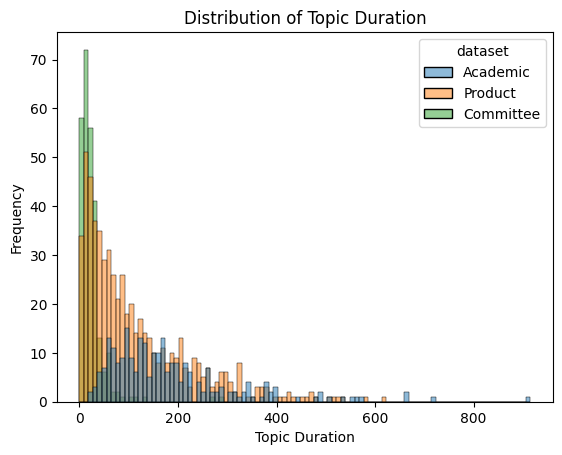

In [19]:
# How long did topics last? Topics should go until they're finished and not flipflop. 
sns.histplot(
    topics_df,
    x="topic_duration",
    bins=100,
    hue="dataset",
    common_norm=False,
    )
plt.xlabel("Topic Duration")
plt.ylabel("Frequency")
plt.title("Distribution of Topic Duration")
plt.show()

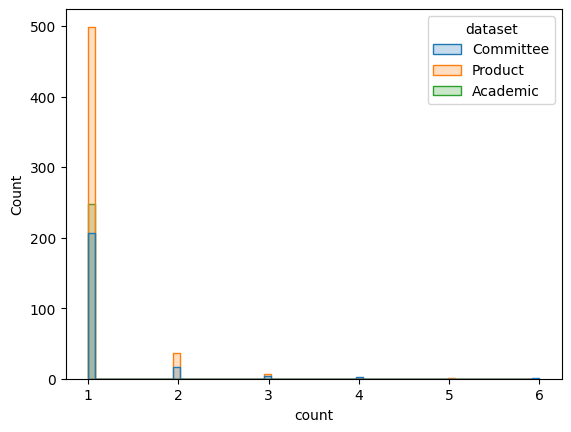

In [20]:
# Do topics repeat after they've been discussed?
effectiveness_df = topics_df[["dataset", "meeting_id", "topic_idx"]].value_counts().reset_index(name="count")

sns.histplot(
    data=effectiveness_df,
    x="count",
    hue="dataset",
    element="step",
    common_norm=False,
    )
plt.show()

### Conflict Detection

In [21]:
summary, turn_ev, topic_ev = score_meetings_for_conflict_resolution(
    transcripts_df,
    topics_df,
    conflict_threshold=6,
    resolution_threshold=6,
    return_evidence=True,
    top_n_turn_evidence=8,
)

/Users/timleong/guidepost/datasets/transcripts_data/qmsum/qmsum_to_pandas.py:173: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = text_series.str.contains(rx, regex=True).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/qmsum_to_pandas.py:173: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = text_series.str.contains(rx, regex=True).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/qmsum_to_pandas.py:173: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = text_series.str.contains(rx, regex=True).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/qmsum_to_pandas.py:173: UserWarning: This pattern i

In [22]:
summary.query("label == 'conflict'").sort_values(
    ["conflict_score", "resolution_score"], ascending=False
).head(20)

,dataset,meeting_id,conflict_score,resolution_score,conflict_turns,resolution_turns,conflict_topic_score,resolution_topic_score,is_conflict,is_resolution,label
22,Academic,Bmr011,50,4,38,2,1,0,True,False,conflict
32,Academic,Bmr024,40,2,30,1,2,0,True,False,conflict
29,Academic,Bmr019,24,0,16,0,0,0,True,False,conflict
23,Academic,Bmr012,21,4,18,2,1,0,True,False,conflict
53,Academic,Bro024,16,4,16,2,0,0,True,False,conflict
154,Product,ES2016d,15,4,8,2,0,0,True,False,conflict
178,Product,IS1006b,14,2,8,1,0,0,True,False,conflict
130,Product,ES2010d,11,4,4,2,0,0,True,False,conflict
196,Product,TS3003d,11,2,7,1,0,0,True,False,conflict
194,Product,TS3003b,10,2,4,1,0,0,True,False,conflict


I don't think we can categorize whether there's conflict through just key words. Context is key and we probably need the LLM to do this.



In [23]:
transcripts_df[transcripts_df["meeting_id"] == "Bmr011"]

,dataset,split,meeting_id,turn_idx,speaker,content,content_clean,n_chars,n_words
18764,Academic,all,Bmr011,0,Professor B,Are we on ? We 're on . OK .,Are we on ? We 're on . OK .,28,10
18765,Academic,all,Bmr011,1,PhD E,Is it on ?,Is it on ?,10,4
18766,Academic,all,Bmr011,2,PhD D,Yeah .,Yeah .,6,2
18767,Academic,all,Bmr011,3,Professor B,"Yeah . OK ,","Yeah . OK ,",11,4
18768,Academic,all,Bmr011,4,PhD D,"One , two {disfmarker} u OK .","One , two u OK .",16,6
...,...,...,...,...,...,...,...,...,...
19917,Academic,all,Bmr011,1153,PhD D,Yeah .,Yeah .,6,2
19918,Academic,all,Bmr011,1154,PhD A,because that {disfmarker} that 'll really help...,because that that 'll really help us .,38,8
19919,Academic,all,Bmr011,1155,Professor B,"O K , uh tea has started out there I suggest w...","O K , uh tea has started out there I suggest w...",78,19
19920,Academic,all,Bmr011,1156,Postdoc G,OK .,OK .,4,2


## Effective Communication

In [24]:

meeting_comm_df = score_qmsum_meeting_communication(
    transcripts_df,
    topics_df=topics_df,
    queries_df=queries_df,
)

meeting_comm_df.head()

/Users/timleong/guidepost/datasets/transcripts_data/qmsum/communication_effectiveness.py:85: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = s.str.contains(rx, regex=True, na=False).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/communication_effectiveness.py:85: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = s.str.contains(rx, regex=True, na=False).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/communication_effectiveness.py:85: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  cols[name] = s.str.contains(rx, regex=True, na=False).astype(int) * int(weight)
/Users/timleong/guidepost/datasets/transcripts_data/qmsum/communication_effe

,dataset,meeting_id,n_turns,lead_speaker,lead_confidence,effective_communication_score,effective_communication,semantic_meaning_score,qa_completion_score,clarification_frequency_score,...,n_speakers,balance_word_entropy,balance_turn_entropy,lead_word_share,lead_turn_share,goal_text_len,alignment_begin,alignment_end,alignment_delta,query_span_coverage
0,Academic,Bdb001,766,Grad C,0.650144,0.556465,False,0.138326,0.112000,0.918407,...,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
1,Academic,Bed002,533,Professor C,0.745143,0.586087,False,0.220771,0.035714,0.976548,...,6,0.776969,0.884760,0.351418,0.294559,964,0.004671,0.007754,0.003083,0.285178
2,Academic,Bed003,1029,Grad B,0.863034,0.608154,True,0.291586,0.149351,0.902818,...,4,0.982118,0.998131,0.258824,0.278912,846,0.005210,0.005375,0.000165,0.094266
3,Academic,Bed004,374,Professor B,0.651929,0.602432,True,0.279590,0.120000,0.899733,...,4,0.793777,0.908532,0.454269,0.374332,963,0.002561,0.005177,0.002616,0.425134
4,Academic,Bed005,709,Professor B,0.650928,0.569029,False,0.199944,0.057377,0.929478,...,6,0.744246,0.884654,0.434009,0.346968,708,0.005045,0.007120,0.002075,0.181946


In [25]:
meetings_scored_df = meetings_df.merge(
    meeting_comm_df,
    on=["dataset", "meeting_id"],
    how="left",
)

meetings_scored_df[[
    "dataset", "meeting_id",
    "lead_speaker", "lead_confidence",
    "semantic_meaning_score",
    "qa_completion_score",
    "clarification_frequency_score",
    "sentiment_stability_score",
    "conversational_balance_score",
    "conversation_convergence_score",
    "effective_communication_score",
    "effective_communication",
]].head()


,dataset,meeting_id,lead_speaker,lead_confidence,semantic_meaning_score,qa_completion_score,clarification_frequency_score,sentiment_stability_score,conversational_balance_score,conversation_convergence_score,effective_communication_score,effective_communication
0,Academic,Bdb001,Grad C,0.650144,0.138326,0.112000,0.918407,0.942037,0.780930,0.447093,0.556465,False
1,Academic,Bed002,Professor C,0.745143,0.220771,0.035714,0.976548,0.983784,0.830864,0.468842,0.586087,False
2,Academic,Bed003,Grad B,0.863034,0.291586,0.149351,0.902818,0.919214,0.990124,0.395828,0.608154,True
3,Academic,Bed004,Professor B,0.651929,0.279590,0.120000,0.899733,0.956419,0.851155,0.507693,0.602432,True
4,Academic,Bed005,Professor B,0.650928,0.199944,0.057377,0.929478,0.981202,0.814450,0.431723,0.569029,False


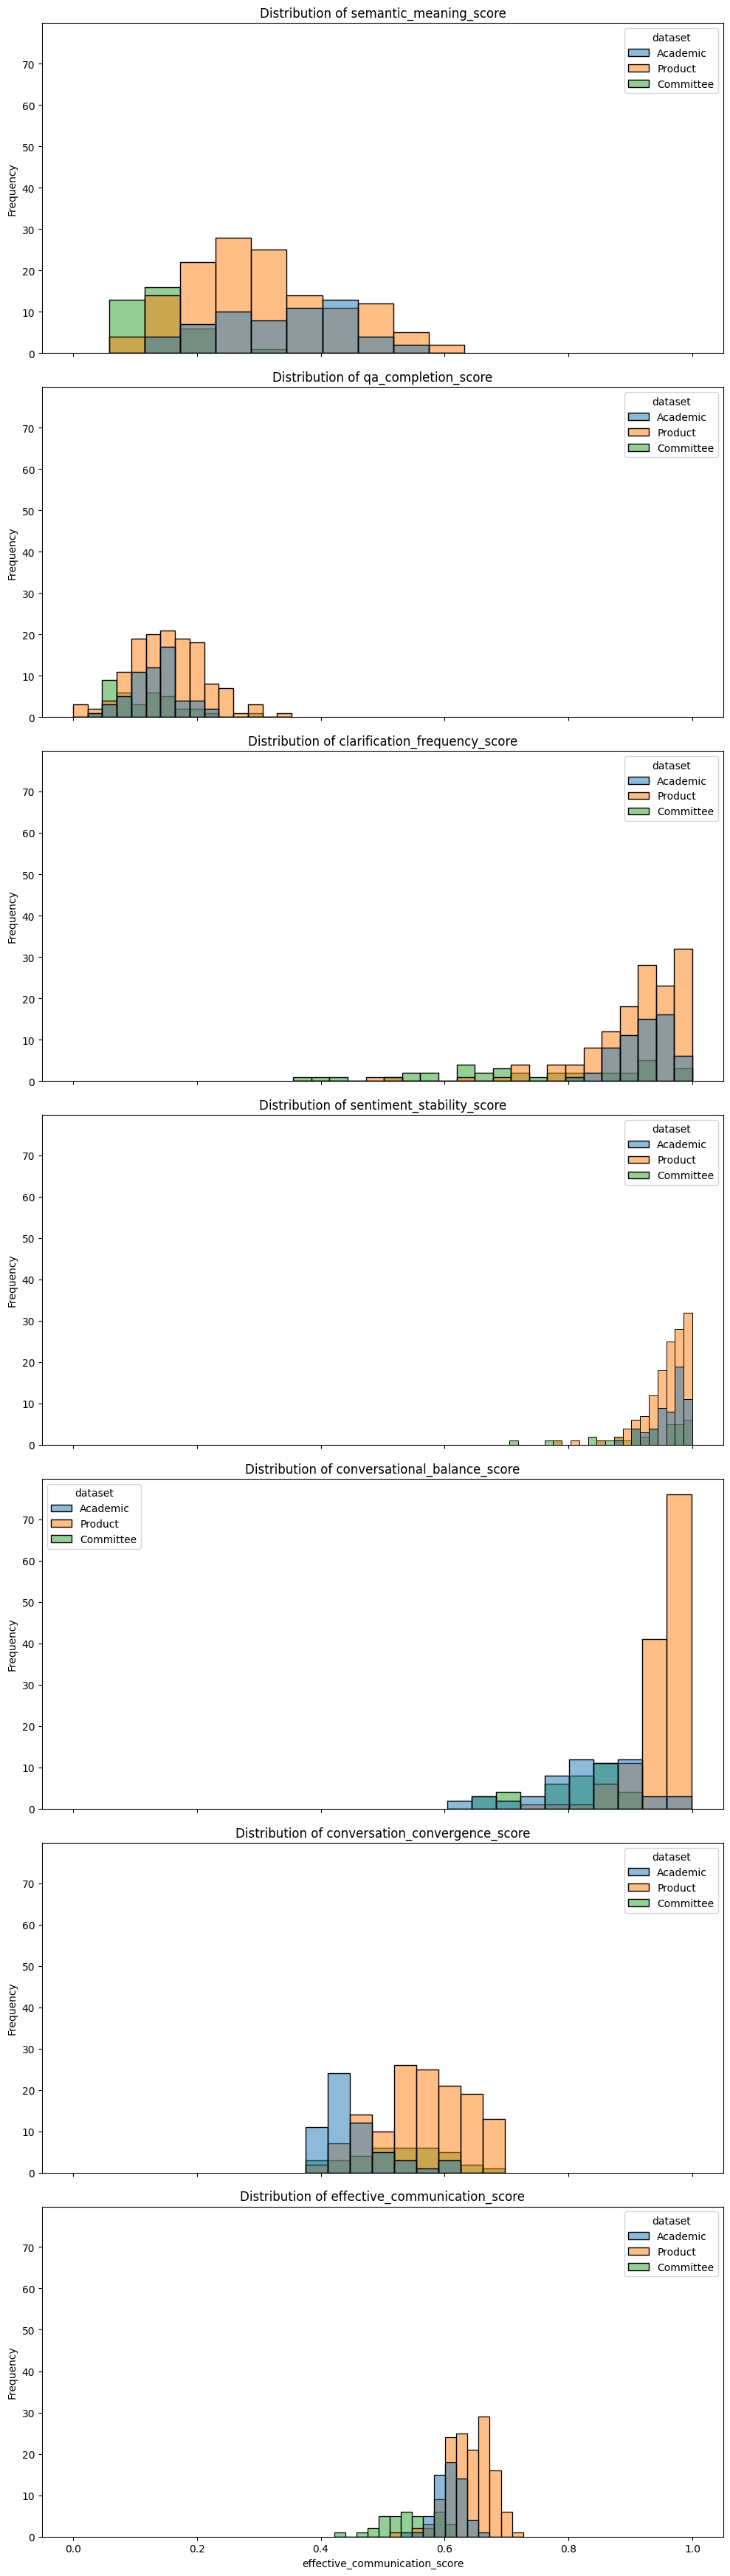

In [38]:
scores = [
    "semantic_meaning_score",
    "qa_completion_score",
    "clarification_frequency_score",
    "sentiment_stability_score",
    "conversational_balance_score",
    "conversation_convergence_score",
    "effective_communication_score"
    ]

fig, ax = plt.subplots(
    nrows=len(scores),
    ncols=1,
    figsize=(10, 5 * len(scores)),
    sharex=True,
    sharey=True,
)

for i, score in enumerate(scores):
    sns.histplot(
        data=meetings_scored_df,
        x=score,
        hue="dataset",
        ax=ax[i],
    )
    ax[i].set_title(f"Distribution of {score}")
    ax[i].set_xlabel(score)
    ax[i].set_ylabel("Frequency")
plt.tight_layout()
plt.show()

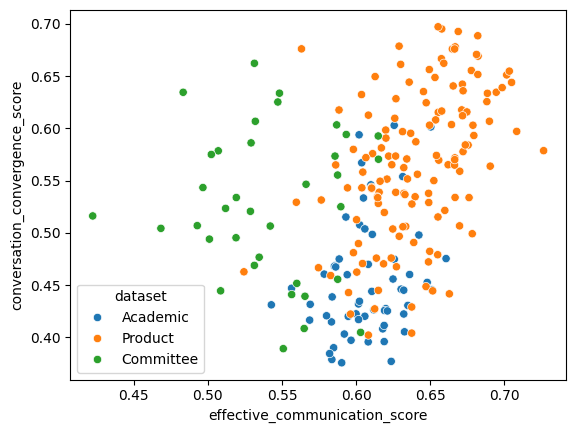

In [43]:
sns.scatterplot(
    data=meetings_scored_df,
    x="effective_communication_score",
    y="conversation_convergence_score",
    hue="dataset",
)

plt.show()

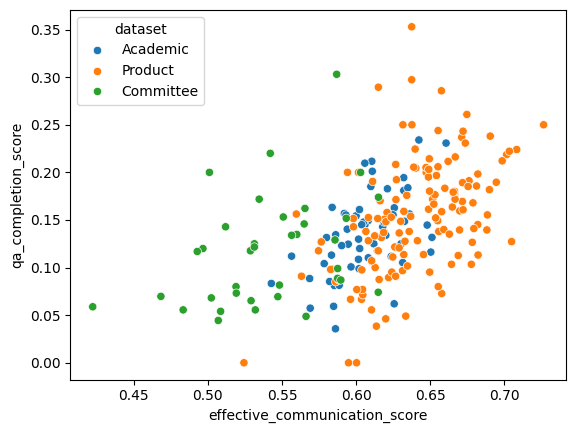

In [42]:
sns.scatterplot(
    data=meetings_scored_df,
    x="effective_communication_score",
    y="qa_completion_score",
    hue="dataset",
)

plt.show()

In [44]:
meetings_scored_df

,dataset,split,meeting_id,n_turns_x,n_topics,n_general_queries,n_specific_queries,meeting_text,meeting_text_chars,meeting_text_words,n_turns_y,lead_speaker,lead_confidence,effective_communication_score,effective_communication,semantic_meaning_score,qa_completion_score,clarification_frequency_score,sentiment_stability_score,conversational_balance_score,conversation_convergence_score,semantic_meaning_raw,n_questions,n_answered,qa_completion_raw,lead_answer_rate_raw,lead_answer_rate_score,lead_answer_eligible_questions,lead_answered_questions,clarification_requests,clarification_provides,clarification_request_rate_per_100_turns,sentiment_begin_mean,sentiment_end_mean,sentiment_delta,sentiment_slope,n_speakers,balance_word_entropy,balance_turn_entropy,lead_word_share,lead_turn_share,goal_text_len,alignment_begin,alignment_end,alignment_delta,query_span_coverage
0,Academic,all,Bdb001,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112000,0.918407,0.942037,0.780930,0.447093,0.084581,125,14,0.112000,0.058140,0.058140,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
1,Academic,all,Bed002,533,5,1,6,"Grad E: I guess .\nGrad A: OK , we 're on . So...",64174,14927,533,Professor C,0.745143,0.586087,False,0.220771,0.035714,0.976548,0.983784,0.830864,0.468842,0.105193,84,3,0.035714,0.030303,0.030303,66,2,1,0,0.187617,0.067223,0.065621,-0.001602,0.009730,6,0.776969,0.884760,0.351418,0.294559,964,0.004671,0.007754,0.003083,0.285178
2,Academic,all,Bed003,1029,3,1,6,Grad C: Nice .\nGrad D: OK .\nGrad A: to to ha...,65809,15318,1029,Grad B,0.863034,0.608154,True,0.291586,0.149351,0.902818,0.919214,0.990124,0.395828,0.122896,154,23,0.149351,0.060345,0.060345,116,7,8,1,0.777454,0.081392,0.037604,-0.043788,-0.048472,4,0.982118,0.998131,0.258824,0.278912,846,0.005210,0.005375,0.000165,0.094266
3,Academic,all,Bed004,374,4,1,6,"Grad A: Hey , you 're not supposed to be drink...",43849,9954,374,Professor B,0.651929,0.602432,True,0.279590,0.120000,0.899733,0.956419,0.851155,0.507693,0.119897,50,6,0.120000,0.028571,0.028571,35,1,3,0,0.802139,0.093333,0.058365,-0.034968,-0.026148,4,0.793777,0.908532,0.454269,0.374332,963,0.002561,0.005177,0.002616,0.425134
4,Academic,all,Bed005,709,4,1,4,"Grad A: Yeah , I think I got my mike on . OK ....",63869,15079,709,Professor B,0.650928,0.569029,False,0.199944,0.057377,0.929478,0.981202,0.814450,0.431723,0.099986,122,7,0.057377,0.013514,0.013514,74,1,4,0,0.564175,0.048239,0.035739,-0.012500,-0.011279,6,0.744246,0.884654,0.434009,0.346968,708,0.005045,0.007120,0.002075,0.181946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
227,Committee,all,education_5,161,6,1,16,"Lynne Neagle AM: Okay. Good morning, everyone....",76426,13262,161,Kirsty Williams AM,0.913663,0.542073,False,0.131775,0.220000,0.767081,0.845982,0.781050,0.506550,0.082944,50,11,0.220000,0.212766,0.212766,47,10,3,0,1.863354,0.196007,0.063281,-0.132726,-0.092411,7,0.655093,0.907008,0.630345,0.341615,1188,0.031813,0.012614,-0.019199,0.546584
228,Committee,all,education_6,179,5,1,12,"Lynne Neagle AM: Good morning, everyone. Welco...",89763,15393,179,Lynne Neagle AM,0.967807,0.614941,True,0.303248,0.074074,0.930168,0.971272,0.818237,0.592649,0.125812,54,4,0.074074,0.076923,0.076923,13,1,1,0,0.558659,0.137191,0.147222,0.010031,0.017237,7,0.821632,0.814843,0.205506,0.379888,1171,0.034039,0.013454,-0.020585,0.815642
229,Committee,all,education_7,262,8,1,12,"Lynne Neagle AM: Good morning, everyone. Welco...",71185,12337,262,Julie Morgan AM,0.861208,0.531345,False,0.080695,0.121622,0.666031,0.968733,0.882038,0.468952,0.070174,74,9,0.121622,0.080645,0.080645,62,5,7,0,2.671756,0.105060,0.070513,-0.034547,-0.018760,9,0.850567,0.913508,0.382485,0.290076,1841,0.026334,0.017697,-

In [45]:
joined_df = transcripts_df.merge(
    meetings_scored_df,
    on=["dataset", "meeting_id"],
    how="left",
)

joined_df.head()

,dataset,split_x,meeting_id,turn_idx,speaker,content,content_clean,n_chars,n_words,split_y,n_turns_x,n_topics,n_general_queries,n_specific_queries,meeting_text,meeting_text_chars,meeting_text_words,n_turns_y,lead_speaker,lead_confidence,effective_communication_score,effective_communication,semantic_meaning_score,qa_completion_score,clarification_frequency_score,sentiment_stability_score,conversational_balance_score,conversation_convergence_score,semantic_meaning_raw,n_questions,n_answered,qa_completion_raw,lead_answer_rate_raw,lead_answer_rate_score,lead_answer_eligible_questions,lead_answered_questions,clarification_requests,clarification_provides,clarification_request_rate_per_100_turns,sentiment_begin_mean,sentiment_end_mean,sentiment_delta,sentiment_slope,n_speakers,balance_word_entropy,balance_turn_entropy,lead_word_share,lead_turn_share,goal_text_len,alignment_begin,alignment_end,alignment_delta,query_span_coverage
0,Academic,all,Bdb001,0,Grad C,"Yeah , we had a long discussion about how much...","Yeah , we had a long discussion about how much...",143,33,all,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112,0.918407,0.942037,0.78093,0.447093,0.084581,125,14,0.112,0.05814,0.05814,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
1,Academic,all,Bdb001,1,PhD D,It {disfmarker} it doesn't {disfmarker},It it doesn't,13,3,all,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112,0.918407,0.942037,0.78093,0.447093,0.084581,125,14,0.112,0.05814,0.05814,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
2,Academic,all,Bdb001,2,Grad C,Did {disfmarker} did {disfmarker} did it {disf...,Did did did it ? I didn't even check yesterday...,70,15,all,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112,0.918407,0.942037,0.78093,0.447093,0.084581,125,14,0.112,0.05814,0.05814,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
3,Academic,all,Bdb001,3,PhD D,It didn't move yesterday either when I started...,It didn't move yesterday either when I started...,51,10,all,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112,0.918407,0.942037,0.78093,0.447093,0.084581,125,14,0.112,0.05814,0.05814,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013
4,Academic,all,Bdb001,4,Grad C,So .,So .,4,2,all,766,5,1,6,"Grad C: Yeah , we had a long discussion about ...",58206,13505,766,Grad C,0.650144,0.556465,False,0.138326,0.112,0.918407,0.942037,0.78093,0.447093,0.084581,125,14,0.112,0.05814,0.05814,86,5,5,0,0.652742,0.055556,0.016667,-0.038889,-0.034778,6,0.765953,0.795907,0.381776,0.353786,774,0.006672,0.005625,-0.001047,0.265013


<Axes: xlabel='effective_communication_score', ylabel='n_words'>

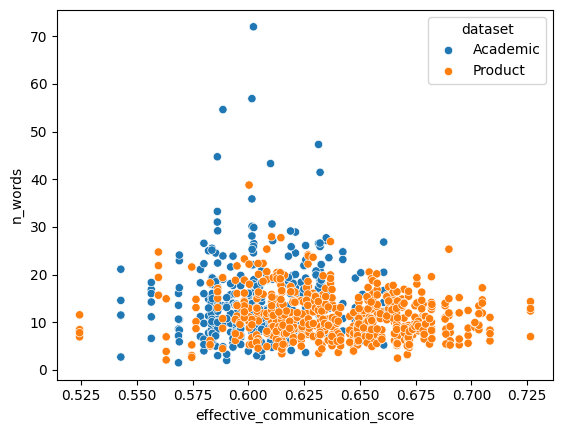

In [58]:
scat_df = joined_df[joined_df["dataset"] != "Committee"].groupby(["dataset", "speaker", "effective_communication_score"]).agg(n_words=("n_words", "mean")).reset_index()

sns.scatterplot(
    data=scat_df,
    x="effective_communication_score",
    y="n_words",
    hue="dataset"
)



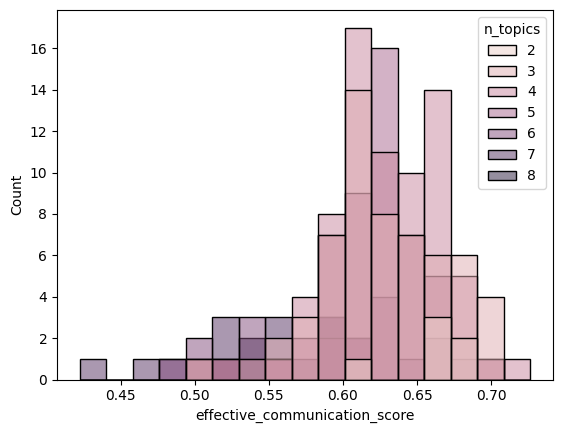

In [63]:
sns.histplot(
    data=meetings_scored_df,
    x="effective_communication_score",
    hue="n_topics",
)

plt.show()
